In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn

In [2]:
transaction_data = pd.read_parquet(r"C:\Users\wwwsi\OneDrive\Documents\Project Brothers BBQ\Dataset _\Cleaned_data\TransactionData_cleaned.parquet")

In [3]:
transaction_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5238 entries, 0 to 5237
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               5238 non-null   datetime64[us]
 1   time_of_purchase   5238 non-null   datetime64[us]
 2   customer_name      5238 non-null   object        
 3   phone_number       5238 non-null   object        
 4   age                4452 non-null   Int64         
 5   age_num            4452 non-null   Int64         
 6   order_type         5238 non-null   object        
 7   item_bought        5238 non-null   object        
 8   is_combo           5238 non-null   object        
 9   quantity           5238 non-null   int64         
 10  item_price_total   5238 non-null   int64         
 11  coupon_used        5238 non-null   object        
 12  discount_amount    5238 non-null   float64       
 13  final_amount       5238 non-null   float64       
 14  payment_method     

In [4]:
transaction_data.isnull().sum()

date                   0
time_of_purchase       0
customer_name          0
phone_number           0
age                  786
age_num              786
order_type             0
item_bought            0
is_combo               0
quantity               0
item_price_total       0
coupon_used            0
discount_amount        0
final_amount           0
payment_method         0
rating                 0
purchase_datetime      0
dtype: int64

In [5]:
transaction_data['age_num'] = transaction_data['age_num'].astype(str)
transaction_data['age_num'] = transaction_data['age_num'].fillna("Unknown")

In [6]:
transaction_data['age_num'].isnull().sum()

np.int64(0)

In [25]:
transaction_data['month'] = transaction_data['date'].dt.month
yearly_sales = transaction_data.groupby('month')['phone_number'].count()

In [31]:
import calendar
yearly_sales.index= [calendar.month_name[m] for m in yearly_sales.index]

In [32]:
yearly_sales.head()

February    1439
March       1316
April       1272
May         1211
Name: phone_number, dtype: int64

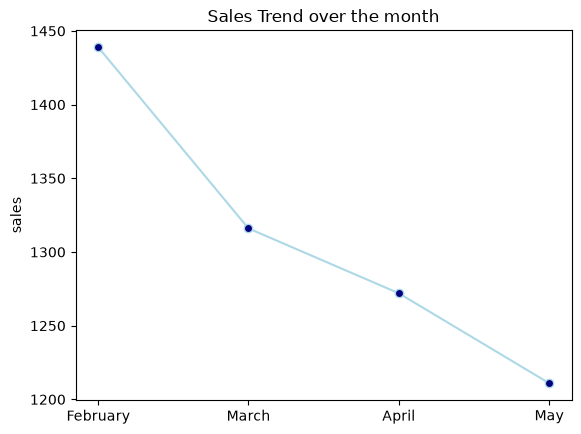

In [37]:
plt.plot(yearly_sales.index,yearly_sales.values,marker = 'o',color = '#ADD8E6',markerfacecolor='navy')
plt.ylabel('sales')
plt.title("Sales Trend over the month")
plt.show()